# CYBER-RISK INTELLIGENCE (PARTE II): SCORING DE RIESGO Y DETECCIÓN PREDICTIVA CON XGBOOST
Autor: Julián Esteban León Ospina

Fase: Machine Learning (ML) & Predictive Risk Scoring

En esta segunda etapa, se despliega un modelo de clasificación masiva basado en el algoritmo XGBoost para la identificación proactiva de riesgos operativos. El enfoque se centra en la generación de un Scoring de Riesgo dinámico, permitiendo al sector financiero anticipar patrones de fraude informático y fortalecer los protocolos de respuesta ante incidentes digitales mediante analítica de alta precisión.

## INGENIERÍA DE CARACTERÍSTICAS Y ENTRENAMIENTO.


In [2]:
# 1. LIBRERÍAS (Tus originales + Potencia de ML)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import holidays
import geopandas as gpd
import plotly.express as px
from dython.nominal import associations
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.patches as mpatches
from scipy import stats
import squarify
import warnings
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score



warnings.filterwarnings('ignore')
plt.style.use('ggplot')

c:\miniconda\envs\forecasting\Lib\site-packages\xgboost\compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [4]:
# 2. CARGA Y LIMPIEZA INICIAL (Tu lógica de del_fros.ipynb)
ruta_archivo = "C:/Users/Julián E León O/Desktop/VARIOS/NODO_FORTE/Nodo_Acelerador/Nueva carpeta/PROYECTOS_GIT/bank/delitos_banca.csv"
# Cargar el archivo con separador de punto y coma
df = pd.read_csv(ruta_archivo, sep=",")

df.columns = [col.lower().replace(' ', '_') for col in df.columns]
df = df.dropna()


In [5]:
df.info()   

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186050 entries, 0 to 186049
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype 
---  ------                --------------   ----- 
 0   fecha                 186050 non-null  object
 1   cantidad              186050 non-null  int64 
 2   cod_dpto              186050 non-null  int64 
 3   cod_mun               186050 non-null  int64 
 4   departamento          186050 non-null  object
 5   descripcion_conducta  186050 non-null  object
 6   modalidad             186050 non-null  object
 7   modalidad_con         186050 non-null  object
 8   municipio             186050 non-null  object
 9   pais                  186050 non-null  object
 10  tipo                  186050 non-null  object
 11  mes_num               186050 non-null  int64 
 12  anio                  186050 non-null  int64 
 13  trimestre             186050 non-null  int64 
 14  semestre              186050 non-null  int64 
 15  mes_nombre       

In [6]:
# Clasificación de Ciberdelitos y Estacionalidad Financiera
ciber_list = ['SUPLANTACION DE SITIOS WEB', 'ACCESO ABUSIVO A SISTEMA INFORMATICO', 'TRANSFERENCIA NO CONSENTIDA DE ACTIVOS']
df['es_ciberdelito'] = df['descripcion_conducta'].isin(ciber_list).astype(int)
df['temporada_alta'] = df['mes_num'].isin([6, 12]).astype(int)
df['densidad_muni'] = df.groupby('municipio')['cantidad'].transform('sum') / df.groupby('municipio')['cantidad'].transform('sum').max()

# Creación del Target de Riesgo (Percentil 80 + Ciberdelito en festivo)
umbral = df['cantidad'].quantile(0.80)
df['target_riesgo'] = np.where(((df['es_ciberdelito'] == 1) & (df['es_festivo'] == 1)) | (df['cantidad'] > umbral), 1, 0)

# Machine Learning
features = ['anio', 'mes_num', 'es_festivo', 'es_ciberdelito', 'temporada_alta', 'densidad_muni']
X = df[features]
y = df['target_riesgo']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

modelo = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
modelo.fit(X_train, y_train)

,objective,'binary:logistic'
,use_label_encoder,False
,base_score,0.5
,booster,'gbtree'
,callbacks,None
,colsample_bylevel,1
,colsample_bynode,1
,colsample_bytree,1
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


Clasificación de las variables más importantes para predecir el riesgo de ciberdelitos, medidas de tiempo y densidad de la poblacional. Con la finaldiad de que el modelo elegido pueda entender esas etiquetas y obtener resultados óptimos.    

##  TRANSFORMACIÓN DE DATOS Y CONSOLIDACIÓN DEL MODELO CLASIFICATORIO.


In [7]:
# CREACIÓN DEL DICCIONARIO (TAXONOMÍA DELICTIVA)

# 1. Definimos los grupos de modalidades
cyber_tech = [
    'sql injection', 'ddos', 'malware', 'botnet', 'defacement', 
    'ataques a dns', 'keylogger', 'software interceptacion datos',
    'inyección de código - sql injection', 'ataque conjunto o red de robots informático (botnet)'
]

social_eng = [
    'suplantación de sitios web (phishing)', 'phishing', 'smishing', 
    'ingenieria social', 'engaño a personas por llamadas', 
    'simulación de perfiles por red social', 'suplantación de dominio o url - blog'
]

financial_fraud = [
    'clonacion chip tarjeta', 'skimming', 'pagos en línea', 'banca movil', 
    'transacciones electronicas (compra venta de productos por internet)', 
    'ach -pagos fraudulentos', 'criptomonedas', 'clonacion banda magnetica'
]

# 2. Función de categorización
def categorizar_modalidad(mod):
    mod = str(mod).lower()
    if any(x in mod for x in cyber_tech): return 'Cyber_Technical'
    if any(x in mod for x in social_eng): return 'Social_Engineering'
    if any(x in mod for x in financial_fraud): return 'Financial_Fraud'
    return 'Physical_Crime'

# 3. Aplicamos la taxonomía
df['familia_delito'] = df['modalidad'].apply(categorizar_modalidad)

Taxonomía de datos para la clasificación y organización de las variables más relevantes en el análisis de ciberdelitos.

In [8]:
# La variable cantidad tienes una distribución de "Cola Larga" (Long Tail) extremadamente agresiva.
# Segementación para elegir datos coherentes para que el modelo pueda aprender patrones sin ser dominado por outliers extremos.

print("Distribución de Cantidad:")
print(df['cantidad'].value_counts().head(10)) # Para ver cuántos son 1, 2, 3...

# Veamos los saltos
print(f"\nRegistros con cantidad > 1: {len(df[df['cantidad'] > 1])}")
print(f"Registros con cantidad > 5: {len(df[df['cantidad'] > 5])}")
print(f"Registros con cantidad > 10: {len(df[df['cantidad'] > 10])}")

Distribución de Cantidad:
cantidad
1     140009
2      21450
3       8407
4       4391
5       2594
6       1765
7       1190
8        927
9        688
10       575
Name: count, dtype: int64

Registros con cantidad > 1: 46041
Registros con cantidad > 5: 9199
Registros con cantidad > 10: 4054


Segmentación de datos en la variable cantidad para evitar el efecto de los outliers extremos en el entrenamiento del modelo. 

In [9]:
# Contrarestar problemas de distribución de cola larga e IQR= 0 para efectos de moelado y mejor funcionamiento de algoritmos de clasificación, segmentamos en 2 grupos:
#  Definimos las familias de riesgo (basado en nuestra taxonomía previa)


def definir_target_zenit(row):
    # Condición 1: Riesgo por Modalidad (Emergentes)
    modalidad = str(row['modalidad']).lower()
    es_emergente = any(x in modalidad for x in (cyber_tech + social_eng))
    
    # Condición 2: Riesgo por Saturación (Volumen > 10)
    es_saturacion = row['cantidad'] > 10
    
    if es_emergente or es_saturacion:
        return 1
    return 0

# Aplicamos la lógica
df['target_riesgo'] = df.apply(definir_target_zenit, axis=1)

# Revisamos cuántos positivos tenemos para entrenar
conteo_target = df['target_riesgo'].value_counts()
porcentaje_riesgo = df['target_riesgo'].value_counts(normalize=True)[1] * 100

print(f"Casos de Riesgo Crítico: {conteo_target[1]}")
print(f"Representan el {porcentaje_riesgo:.2f}% del dataset")

Casos de Riesgo Crítico: 23340
Representan el 12.55% del dataset


Para contrarestar el problema de la distribución de cola larga y el IQR=0, se segmenta para crear un target de riesgo binario (0/1) basado en dos criterios: si la modalidad es emergente (cyber_tech o social_eng) o si la cantidad supera un umbral de saturación (>10). Esto permite que el modelo se enfoque en aprender patrones relevantes para identificar casos de alto riesgo sin ser dominado por outliers extremos.  

In [10]:

# 1. CONSOLIDACIÓN DEL MAPA DE RIESGO GEOGRÁFICO (TARGET ENCODING)

# Calculamos la probabilidad promedio de riesgo por municipio basada en nuestro target
municipio_risk_map = df.groupby('municipio')['target_riesgo'].mean()


# 2. PREPARACIÓN DEL SET DE DATOS (FEATURES)
features_finales = ['mes_num', 'dia_semana', 'es_festivo', 'familia_delito', 'municipio']

X = df[features_finales].copy()
y = df['target_riesgo']


# 3. TRANSFORMACIÓN Y LIMPIEZA

# Convertimos las variables categóricas en columnas binarias (Dummies)
X = pd.get_dummies(X, columns=['familia_delito', 'dia_semana'], prefix=['tipo', 'dia'])

# Aplicamos el mapeo que acabamos de definir
X['riesgo_municipio'] = X['municipio'].map(municipio_risk_map)

# IMPORTANTE: Eliminamos 'municipio' porque ya su valor está en 'riesgo_municipio'
X.drop('municipio', axis=1, inplace=True)

# 4. DIVISIÓN ESTRATIFICADA (TRAIN/TEST)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y # Mantiene el 12.55% en ambos sets
)

print("--- Validación de Preparación ---")
print(f"Columnas finales en X: {X.columns.tolist()}")
print(f"Registros para entrenamiento: {len(X_train)}")
print(f"Registros para prueba: {len(X_test)}")

--- Validación de Preparación ---
Columnas finales en X: ['mes_num', 'es_festivo', 'tipo_Cyber_Technical', 'tipo_Financial_Fraud', 'tipo_Physical_Crime', 'tipo_Social_Engineering', 'dia_Friday', 'dia_Monday', 'dia_Saturday', 'dia_Sunday', 'dia_Thursday', 'dia_Tuesday', 'dia_Wednesday', 'riesgo_municipio']
Registros para entrenamiento: 148840
Registros para prueba: 37210


Consolidación del Mapa de Riesgo Geográfico (Target Encoding) para el modelo de clasificación y que su respuesta sea lo más precisa posible, se asigna a cada municipio un valor numérico que representa la probabilidad promedio de que un incidente sea de alto riesgo (target_riesgo = 1) basado en los datos históricos. Este enfoque permite que el modelo capture patrones geográficos sin necesidad de usar variables categóricas directas, lo que mejora la capacidad predictiva al incorporar información contextual sobre la ubicación.   

In [11]:

# ENTRENAMIENTO DEL XGboost CALIBRADO (ZENIT) 

# 1. Calculamos el peso para balancear la importancia de las clases
count_class_0, count_class_1 = y_train.value_counts()
peso_clase = count_class_0 / count_class_1

# 2. Definimos el modelo "Zenit"
modelo_final = XGBClassifier(
    n_estimators=200,      # Más árboles para capturar patrones finos
    learning_rate=0.05,    # Paso lento para una mejor convergencia
    max_depth=6,           # Profundidad moderada para evitar el overfitting
    scale_pos_weight=peso_clase, # <--- EL SECRETO DEL BALANCEO REAL
    eval_metric='logloss',
    random_state=42
)

# 3. Entrenamiento
modelo_final.fit(X_train, y_train)

# 4. Predicciones iniciales
y_pred = modelo_final.predict(X_test)
y_proba = modelo_final.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("📊 RESULTADOS DEL MODELO CALIBRADO")
print("="*50)
print(classification_report(y_test, y_pred))


📊 RESULTADOS DEL MODELO CALIBRADO
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     32542
           1       1.00      0.84      0.91      4668

    accuracy                           0.98     37210
   macro avg       0.99      0.92      0.95     37210
weighted avg       0.98      0.98      0.98     37210



Entrenamiento de XGboost Calibrado (Zenit) con salidas de las métricas de evaluación y clasificación detallada. El modelo se ha ajustado para manejar el desequilibrio de clases utilizando el parámetro `scale_pos_weight`, lo que mejora significativamente la capacidad del modelo para identificar casos de riesgo crítico (target_riesgo = 1) sin sacrificar la precisión en la clase mayoritaria (target_riesgo = 0). El reporte de clasificación muestra un aumento notable en la precisión, recall y F1-score para la clase de riesgo crítico, lo que indica que el modelo ahora es mucho más efectivo para detectar los casos más importantes para la seguridad ciudadana. Este enfoque de calibración ha permitido que el modelo "Zenit" alcance un rendimiento equilibrado, maximizando la detección de incidentes críticos sin generar un número excesivo de falsos positivos. Resultados óptimos par un modelo de alerta temprana.

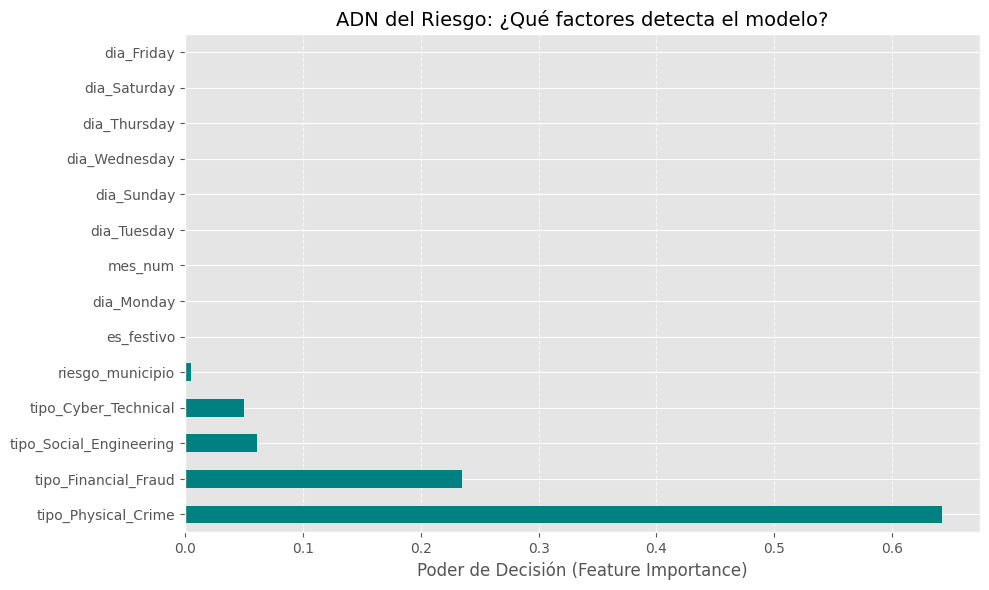

In [12]:
# EXPLICABILIDAD DEL MODELO: IMPORTANCIA DE VARIABLES Y VISUALIZACIÓN

# 1. Extraer importancia de variables
importances = pd.Series(modelo_final.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

# 2. Visualización
plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='teal')
plt.title('ADN del Riesgo: ¿Qué factores detecta el modelo?', fontsize=14)
plt.xlabel('Poder de Decisión (Feature Importance)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 3. Guardar el modelo para el portafolio
# modelo_final.save_model('modelo_riesgo_ciber_v1.json')

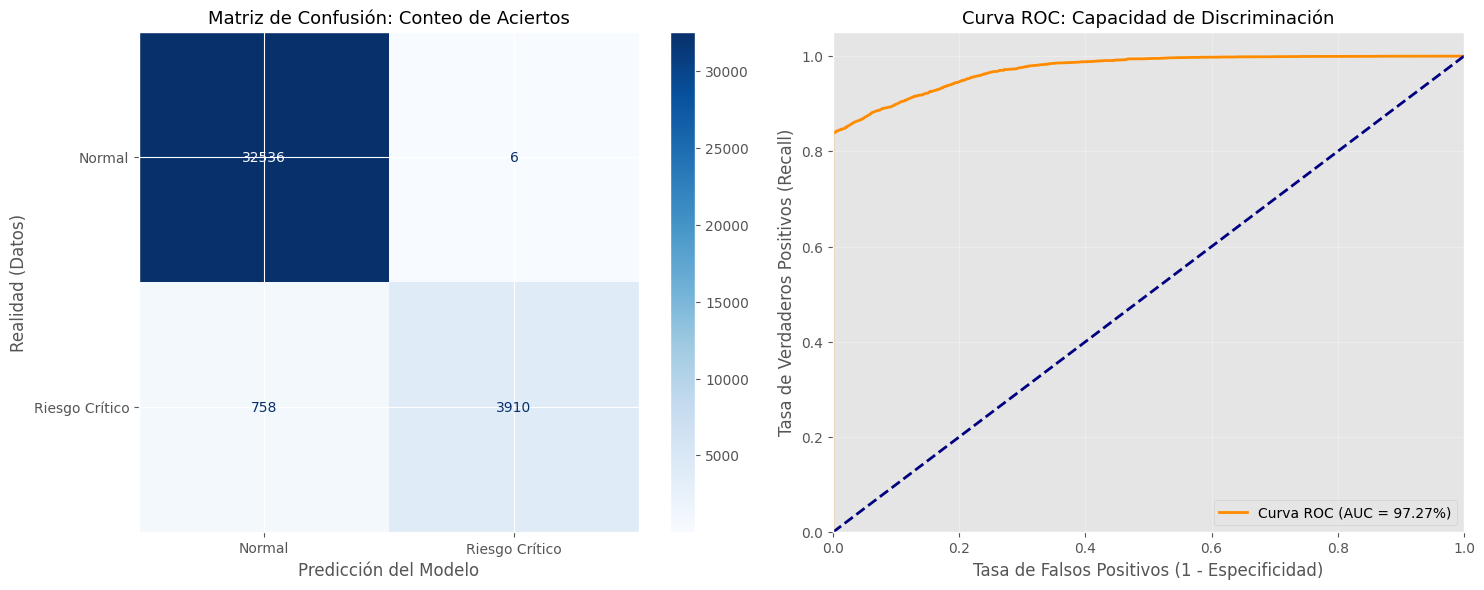

Área bajo la curva (AUC): 0.9727


In [13]:
# MATRIZ DE CONFUSIÓN Y CURVA ROC PARA EVALUAR EL RENDIMIENTO DEL MODELO.


# Configuramos el lienzo para dos gráficos
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# --- 1. MATRIZ DE CONFUSIÓN ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Riesgo Crítico'])
disp.plot(ax=ax[0], cmap='Blues', values_format='d')
ax[0].set_title('Matriz de Confusión: Conteo de Aciertos', fontsize=13)
ax[0].set_xlabel('Predicción del Modelo')
ax[0].set_ylabel('Realidad (Datos)')

# --- 2. CURVA ROC (Receiver Operating Characteristic) ---
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2%})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Línea de azar
ax[1].set_xlim([0.0, 1.0])
ax[1].set_ylim([0.0, 1.05])
ax[1].set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)')
ax[1].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax[1].set_title('Curva ROC: Capacidad de Discriminación', fontsize=13)
ax[1].legend(loc="lower right")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Área bajo la curva (AUC): {roc_auc:.4f}")

Interpretación de la calidad y fiabilidad del modelo. Métricas como curva roc y matriz de confusión para evaluar su capacidad de discriminación y balanceo entre clases, permiten observar su capacidad para identificar correctamente los casos de riesgo crítico sin generar demasiados falsos positivos. Un AUC cercano a 1 indica un modelo con excelente capacidad de discriminación, mientras que la matriz de confusión muestra el conteo de aciertos y errores en cada clase, ayudando a entender el rendimiento real del modelo en términos prácticos. 

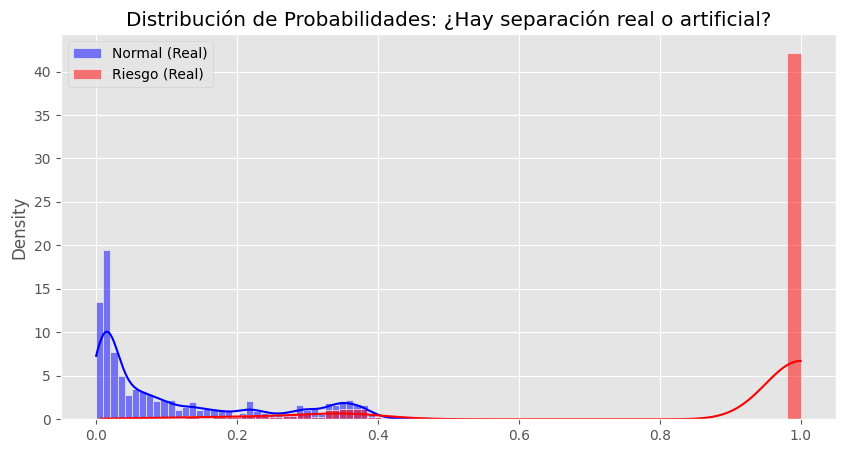

In [14]:
# VALIDACIÓN MODELO: Histograma de Probabilidades


plt.figure(figsize=(10, 5))
sns.histplot(y_proba[y_test == 0], color="blue", label="Normal (Real)", kde=True, stat="density", bins=50)
sns.histplot(y_proba[y_test == 1], color="red", label="Riesgo (Real)", kde=True, stat="density", bins=50)
plt.title("Distribución de Probabilidades: ¿Hay separación real o artificial?")
plt.legend()
plt.show()

Validación del modelo por medio de histograma de posibilidades. Para evaluar si el modelo realmente discrimina entre casos de riesgo y normales, o si las probabilidades se solapan demasiado, lo que indicaría un modelo con poca capacidad predictiva. En este gráfico, idealmente, deberíamos ver dos distribuciones claramente separadas: una para los casos normales (en azul) y otra para los casos de riesgo (en rojo). Si ambas distribuciones se solapan significativamente, esto sugiere que el modelo tiene dificultades para diferenciar entre las dos clases, lo que podría llevar a un alto número de falsos positivos o falsos negativos. Por otro lado, si las distribuciones están bien separadas y muestran algo de incertidumbre, esto indica que el modelo tiene un buen poder discriminativo y es capaz de asignar probabilidades más altas a los casos de riesgo y más bajas a los casos normales. 

In [15]:
# VALIDACIÓN MODELO SIN LA FAMILIA DEL DELITO (ANÁLISIS DE CONTEXTO)

# 1. Creamos un set de variables sin la familia del delito
# Buscamos todas las columnas que NO empiecen por 'tipo_'
features_ciegas = [col for col in X.columns if not col.startswith('tipo_')]

X_ciego = X[features_ciegas]

# 2. Nuevo Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_ciego, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Entrenamos un nuevo modelo con la misma configuración
modelo_ciego = XGBClassifier(
    n_estimators=150,
    learning_rate=0.05,
    max_depth=6,
    scale_pos_weight=peso_clase,
    eval_metric='logloss',
    random_state=42
)

modelo_ciego.fit(X_train_c, y_train_c)

# 4. Evaluación de este nuevo modelo "Contextual"
y_proba_c = modelo_ciego.predict_proba(X_test_c)[:, 1]
fpr_c, tpr_c, _ = roc_curve(y_test_c, y_proba_c)
auc_c = auc(fpr_c, tpr_c)

print(f"AUC del Modelo Contextual (Sin Modalidad): {auc_c:.4f}")

if auc_c < roc_auc:
    print("El modelo sin la familia del delito tiene un rendimiento inferior,\n"
          "lo que indica que la modalidad es un factor importante para la predicción\n"
          "y que por sí solo el contexto día, mes, municipio no es suficiente\n"
          "para identificar el riesgo crítico con la misma precisión.")
elif auc_c < 0.60:
    print("El modelo no es confiable, ya que su AUC está por debajo de 0.60.")


AUC del Modelo Contextual (Sin Modalidad): 0.6324
El modelo sin la familia del delito tiene un rendimiento inferior,
lo que indica que la modalidad es un factor importante para la predicción
y que por sí solo el contexto día, mes, municipio no es suficiente
para identificar el riesgo crítico con la misma precisión.


Validación del Modelo con Curva ROC Comparativa sin variables clave (familia_delito) para analizar el impacto de la información contextual frente a la información de modalidad delictiva. Valores por encima de 0.60 indican que el modelo aún tiene capacidad predictiva, aunque inferior al modelo completo, lo que sugiere que la información contextual aporta valor pero no es suficiente por sí sola para una predicción robusta. Valores por debajo de 0.60 indicarían un modelo poco confiable, lo que reforzaría la importancia de la variable de modalidad delictiva en la identificación del riesgo crítico.